# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [1]:
# Importing necessary libraries
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt; import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings; warnings.filterwarnings('ignore')

#### **1.1.1**
Load the dataset

In [2]:
# Load the data
df = pd.read_csv("Car_Price_data.csv")
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns}')
df.head()

Shape: (15915, 23)
Columns: Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras',
       'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb'],
      dtype='object')


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [4]:
# Find the proportion of missing values in each column and handle if found
df.isnull().mean()*100

make_model             0.0
body_type              0.0
price                  0.0
vat                    0.0
km                     0.0
Type                   0.0
Fuel                   0.0
Gears                  0.0
Comfort_Convenience    0.0
Entertainment_Media    0.0
Extras                 0.0
Safety_Security        0.0
age                    0.0
Previous_Owners        0.0
hp_kW                  0.0
Inspection_new         0.0
Paint_Type             0.0
Upholstery_type        0.0
Gearing_Type           0.0
Displacement_cc        0.0
Weight_kg              0.0
Drive_chain            0.0
cons_comb              0.0
dtype: float64

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

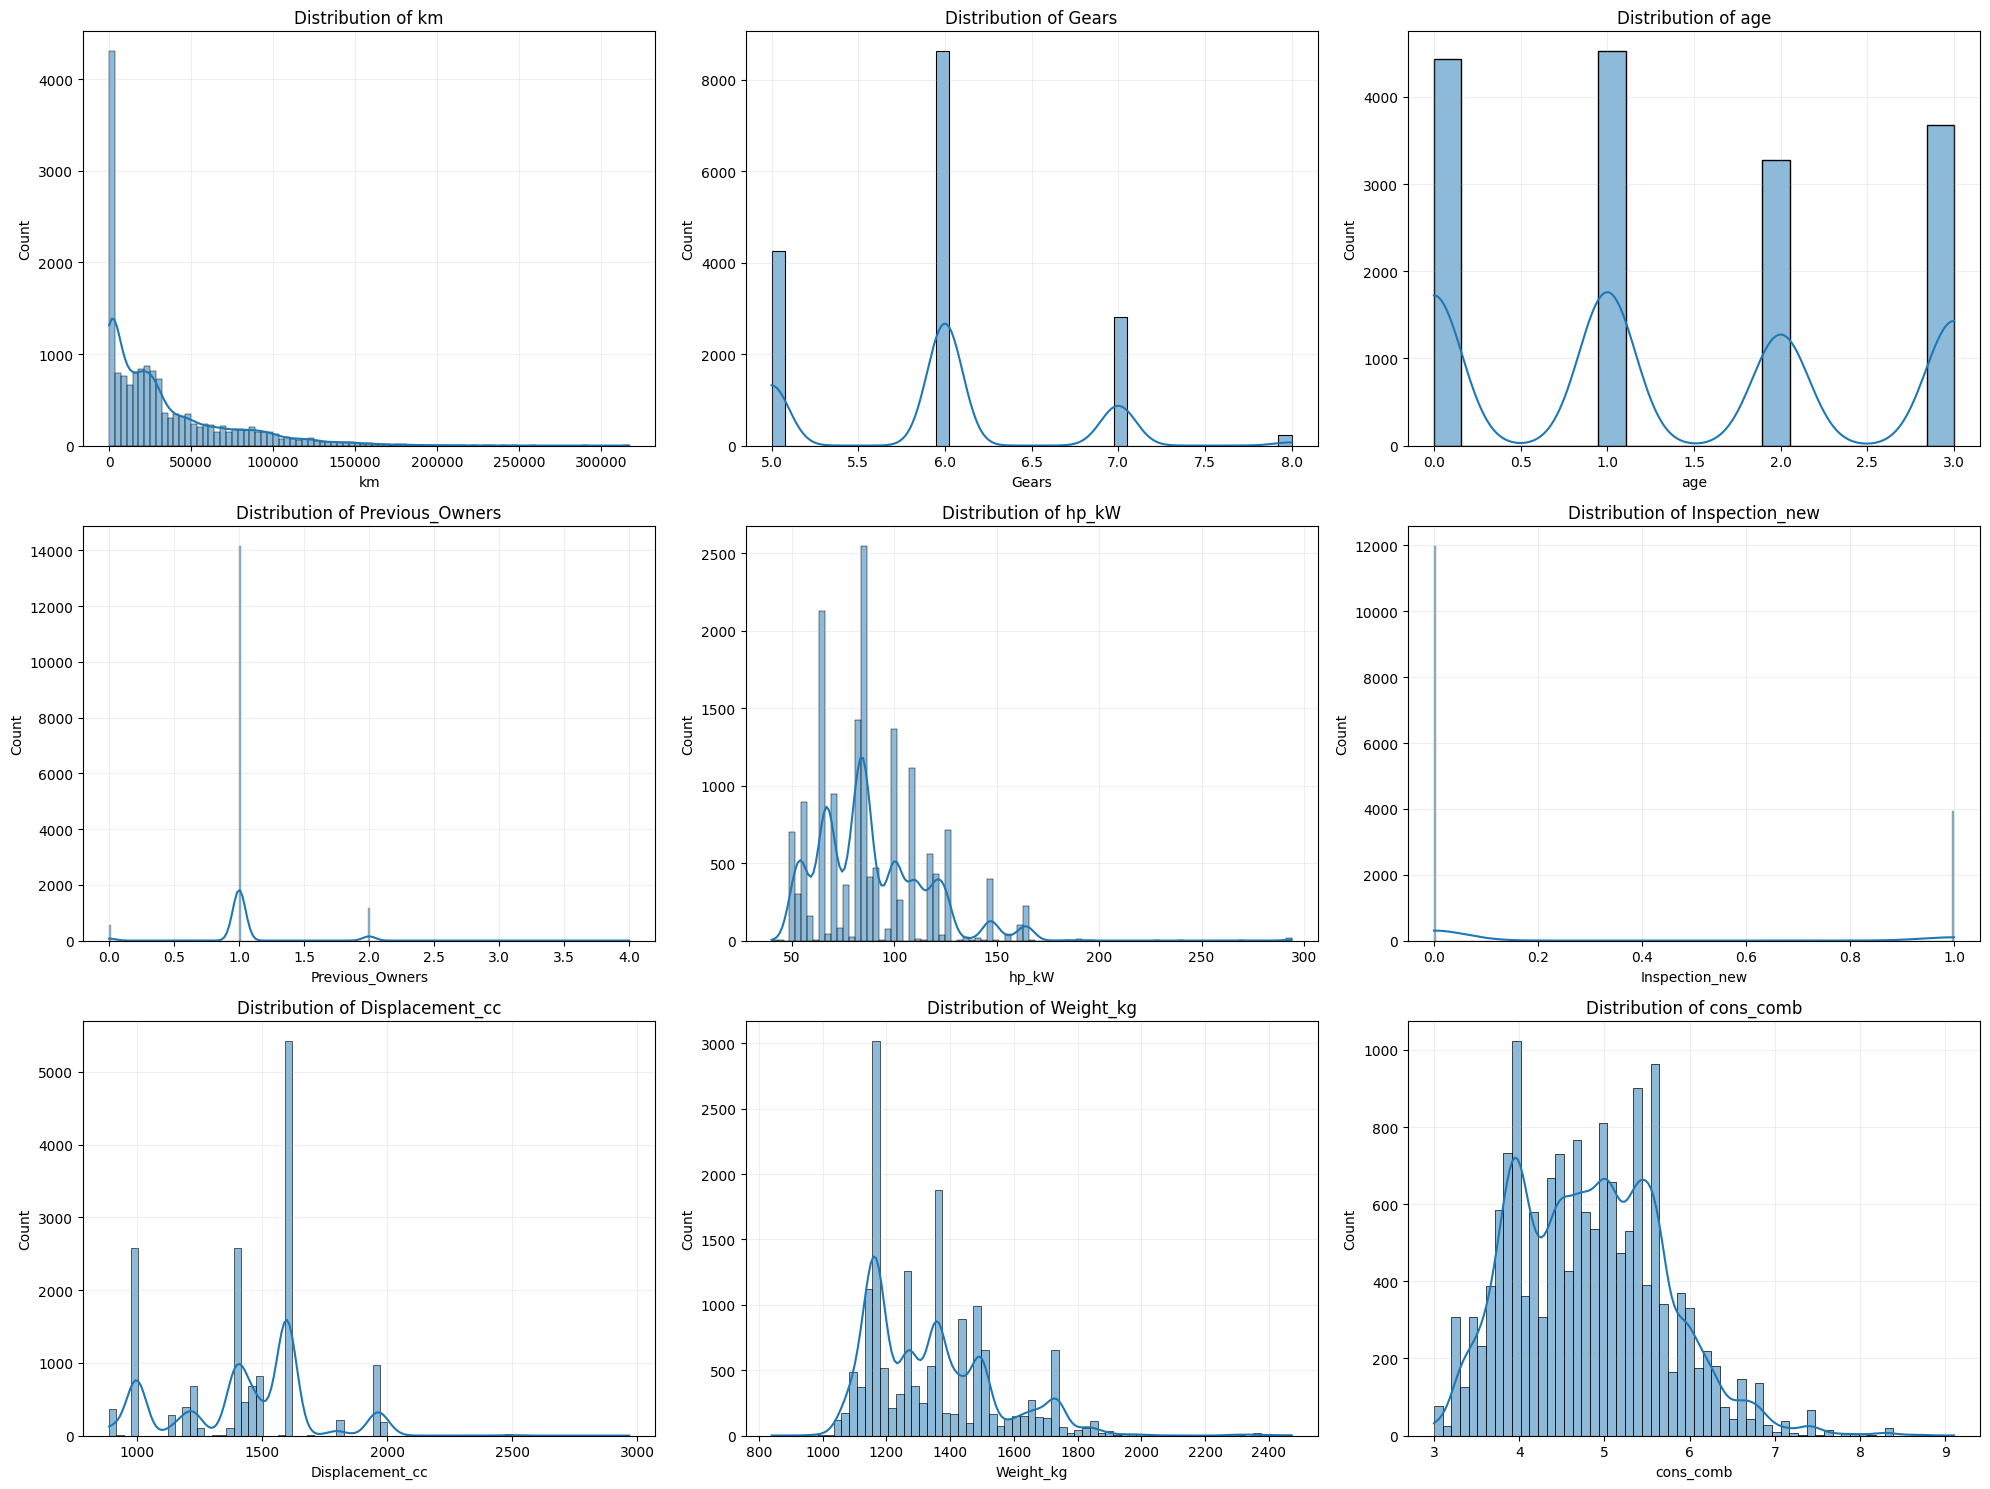

In [5]:
# Identify numerical features and plot histograms
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fix: Check for the string, not a list, and reassign the dropped index
target_name = 'price'
if target_name in numerical_cols:
    numerical_cols = numerical_cols.drop(target_name)

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.grid(True,alpha = 0.2)

plt.tight_layout()
plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [6]:
df.describe(include='object').T

,count,unique,top,freq
make_model,15915,9,Audi A3,3097
body_type,15915,8,Sedans,8004
vat,15915,2,VAT deductible,15044
Type,15915,5,Used,11095
Fuel,15915,4,Benzine,8548
Comfort_Convenience,15915,6196,"Air conditioning,Electrical side mirrors,Hill ...",388
Entertainment_Media,15915,346,"Bluetooth,Hands-free equipment,On-board comput...",1737
Extras,15915,659,Alloy wheels,5785
Safety_Security,15915,4442,"ABS,Central door lock,Daytime running lights,D...",729
Paint_Type,15915,3,Metallic,15246


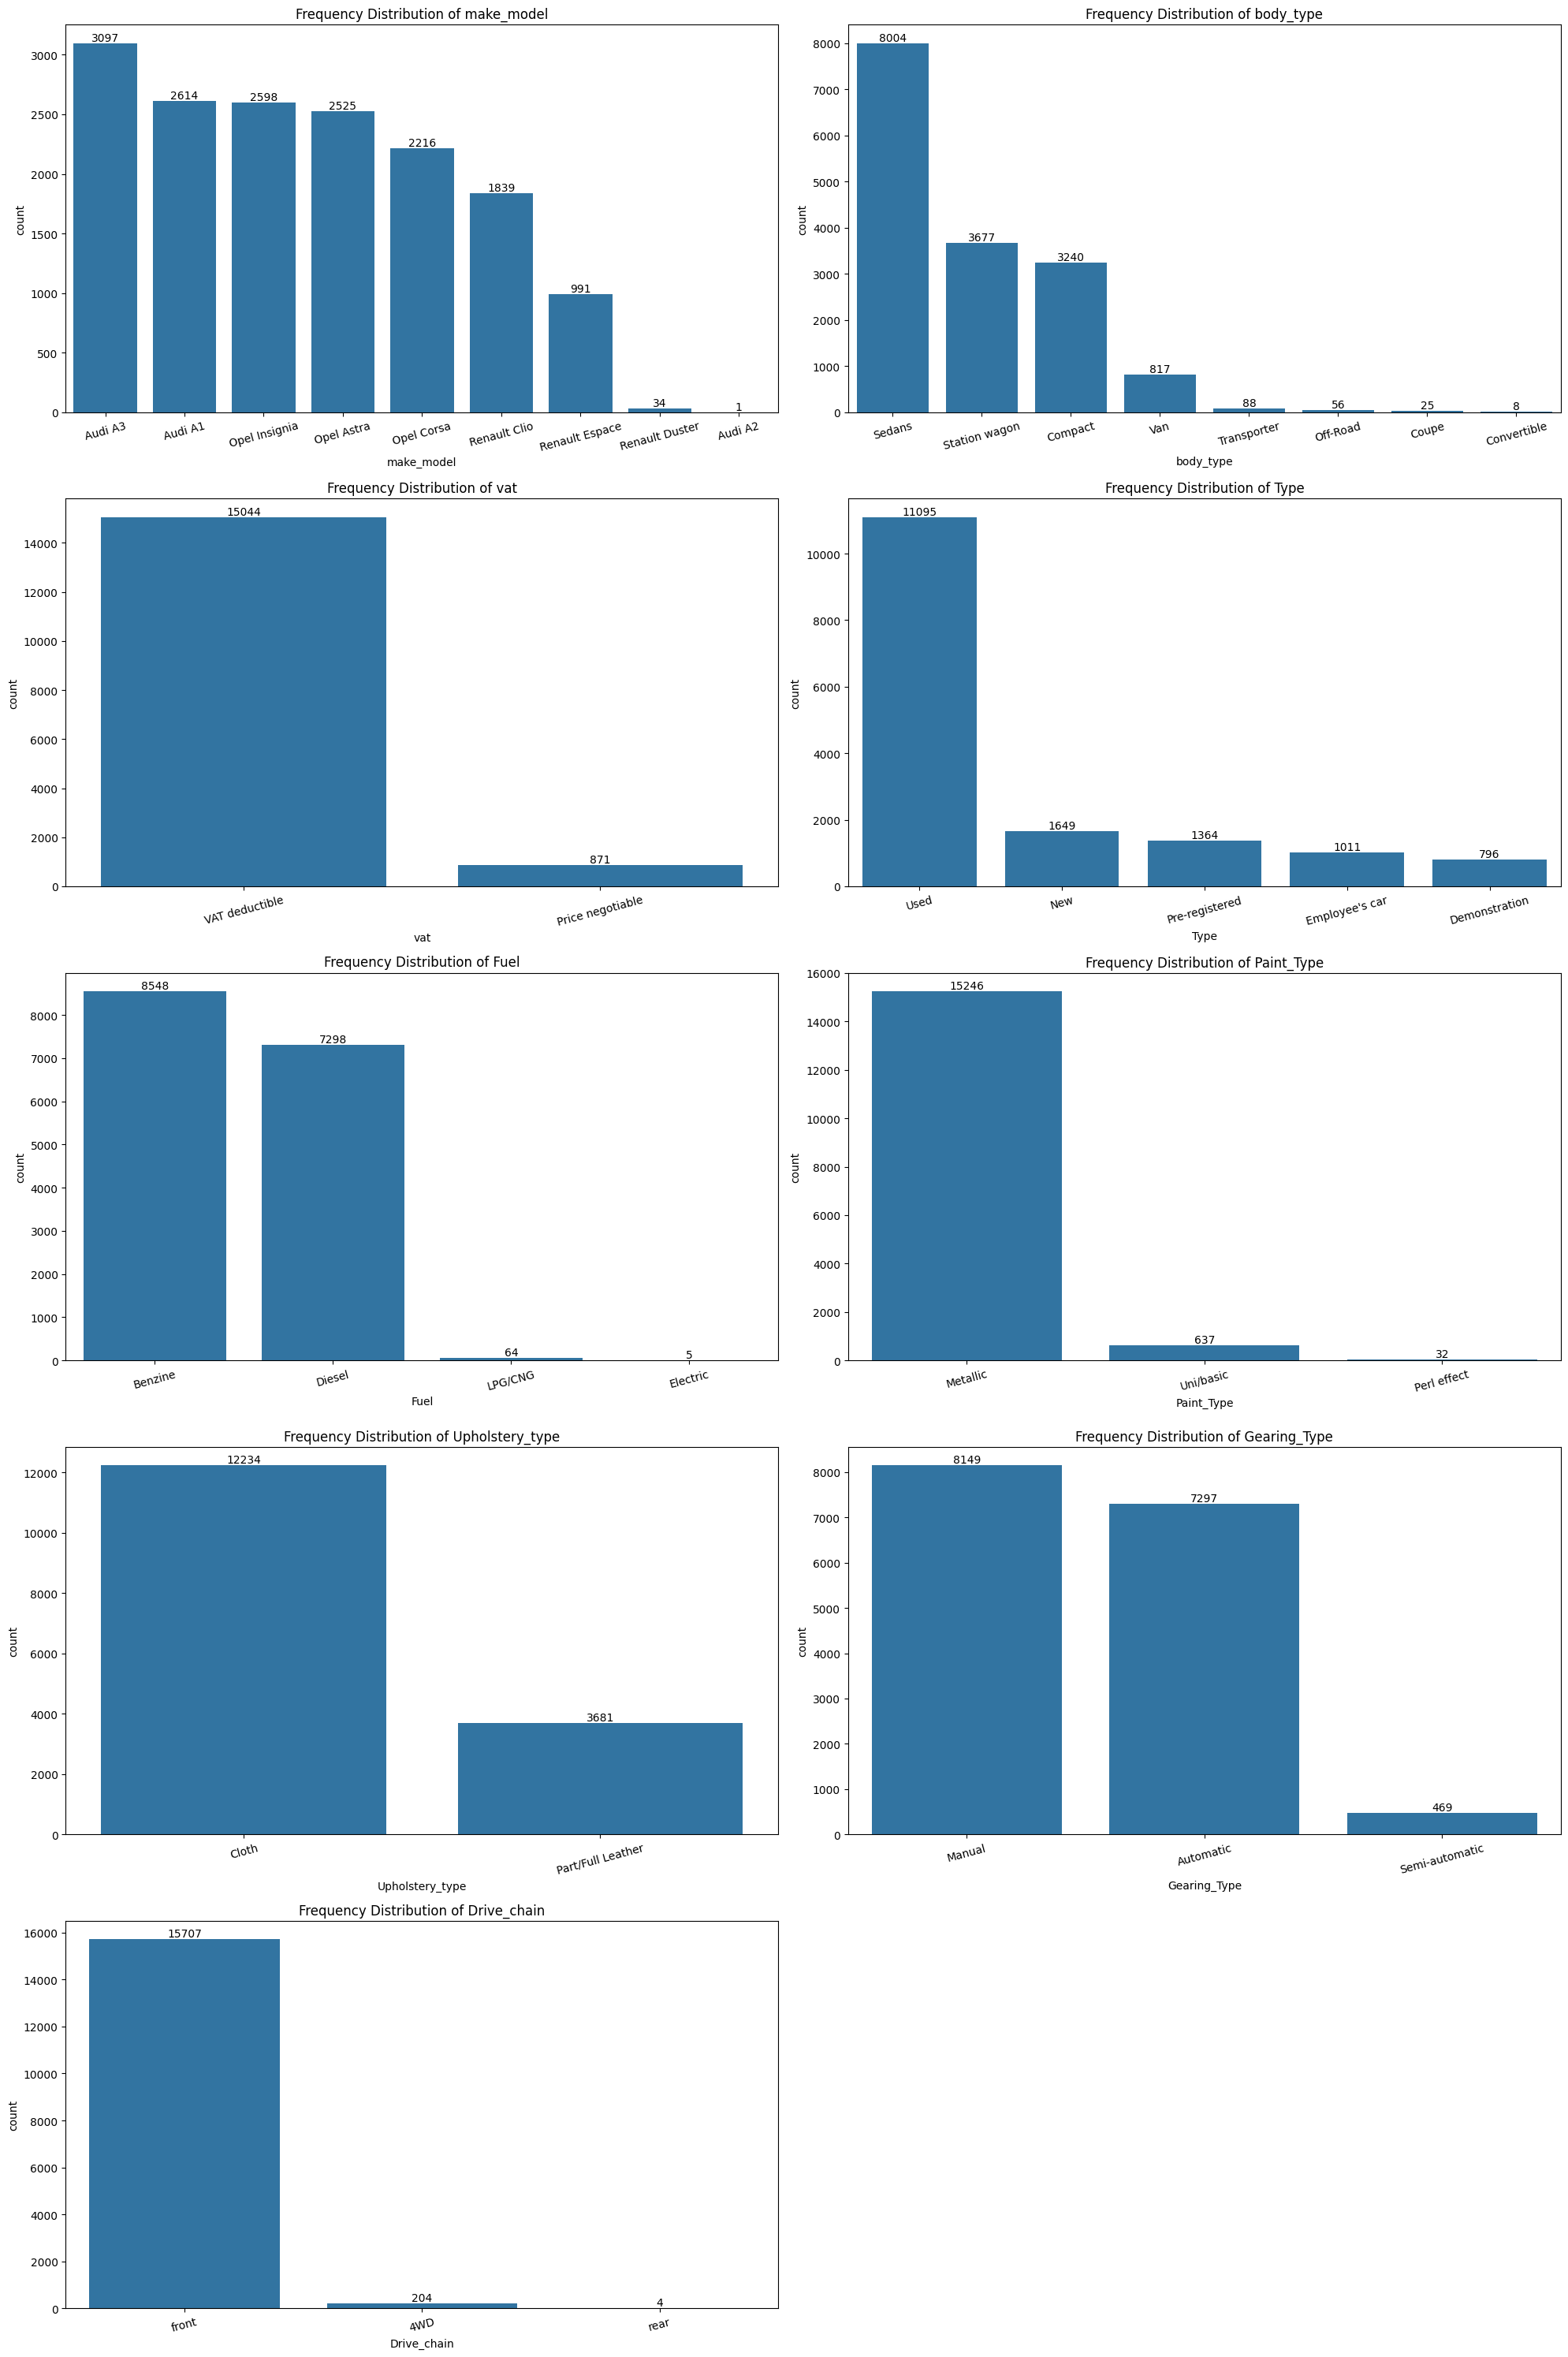

Column Comfort_Convenience has 6196 unique values. Skipping plot.
Column Entertainment_Media has 346 unique values. Skipping plot.
Column Extras has 659 unique values. Skipping plot.
Column Safety_Security has 4442 unique values. Skipping plot.


In [7]:
# Identify categorical columns and check their frequency distributions
categorical_cols = df.select_dtypes(include=['object']).columns

plot_cols = [col for col in categorical_cols if df[col].nunique()<10]
n_cols = 2
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(plot_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    ax=sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Frequency Distribution of {col}')
    plt.xticks(rotation=15)
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()

# Reporting columns with too many unique values
for col in categorical_cols:
    if col not in plot_cols:
        print(f'Column {col} has {df[col].nunique()} unique values. Skipping plot.')

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [8]:
cols = ["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]

for col in cols:
    print(f'Column {col} has {df[col].nunique()} unique values.\n')
    r = df[col].value_counts().reset_index(name='count').rename(columns={'index': 'values'})
    print(r)

Column Comfort_Convenience has 6196 unique values.

                                    Comfort_Convenience  count
0     Air conditioning,Electrical side mirrors,Hill ...    388
1     Air conditioning,Armrest,Automatic climate con...    187
2     Air conditioning,Armrest,Automatic climate con...    161
3     Air conditioning,Automatic climate control,Cru...    160
4     Air conditioning,Electrical side mirrors,Power...    134
...                                                 ...    ...
6191  Air conditioning,Automatic climate control,Cru...      1
6192  Air conditioning,Automatic climate control,Cru...      1
6193  Air conditioning,Armrest,Automatic climate con...      1
6194  Air conditioning,Armrest,Automatic climate con...      1
6195  Air conditioning,Air suspension,Automatic clim...      1

[6196 rows x 2 columns]
Column Entertainment_Media has 346 unique values.

                                   Entertainment_Media  count
0    Bluetooth,Hands-free equipment,On-board comput...

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [9]:
# Fix columns as needed
df_1 = df.copy()

# Type column handling
df_1['Type'] = df_1['Type'].replace(['Pre-registered','New',"Employee's car",'Demonstration'],'Like New')

# categories with less than 1% frequency will be grouped as 'Other'
threshold = 0.01
for col in categorical_cols:
    if col != 'Type':
        freq = df_1[col].value_counts(normalize=True)
        low_freq_cats = freq[freq < threshold].index
        if len(low_freq_cats) > 0:
            df_1[col] = df_1[col].replace(low_freq_cats, 'Other')

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

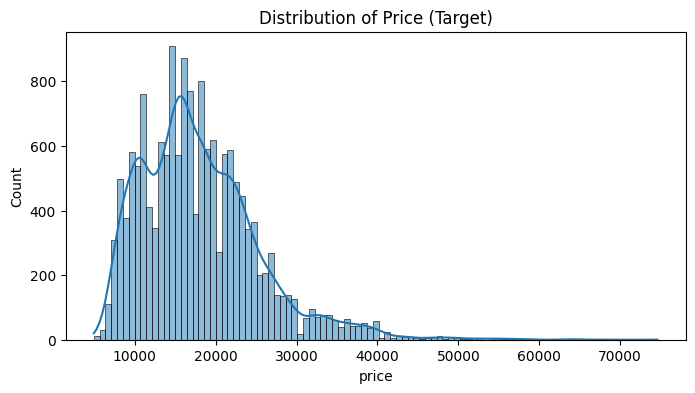

In [10]:
# Plot histograms for target feature
plt.figure(figsize=(8, 4))
sns.histplot(df_1['price'], kde=True)
plt.title('Distribution of Price (Target)')
plt.show()

In [11]:
print(f'The distribution target variable is right skewed with skew value of {df_1["price"].skew().round(4)}, \nwhich is greater than 1 and can be problematic for model building.')

The distribution target variable is right skewed with skew value of 1.2362, 
which is greater than 1 and can be problematic for model building.


**The target variable seems to be skewed. Perform suitable transformation on the target.**

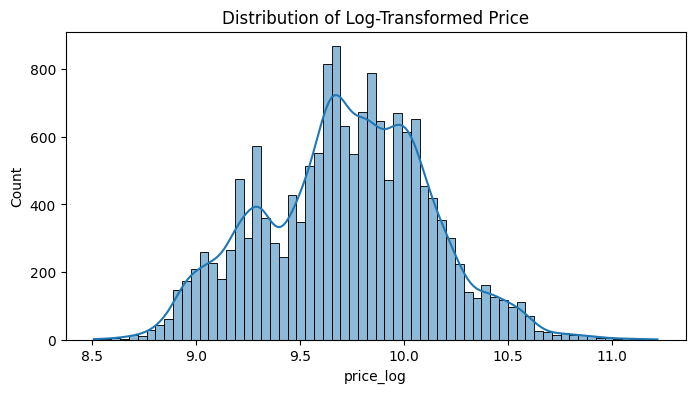

In [12]:
# Transform the target feature
df_1['price_log'] = np.log(df_1['price'])

# Visualizing the transformed target
plt.figure(figsize=(8, 4))
sns.histplot(df_1['price_log'], kde=True)
plt.title('Distribution of Log-Transformed Price')
plt.show()

In [13]:
df_1 = df_1.drop(['price'], axis=1)

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

price_log          1.000000
hp_kW              0.678022
Gears              0.588196
Weight_kg          0.464596
Displacement_cc    0.254852
cons_comb          0.211094
Inspection_new     0.030928
Previous_Owners   -0.152029
km                -0.419190
age               -0.474617
Name: price_log, dtype: float64

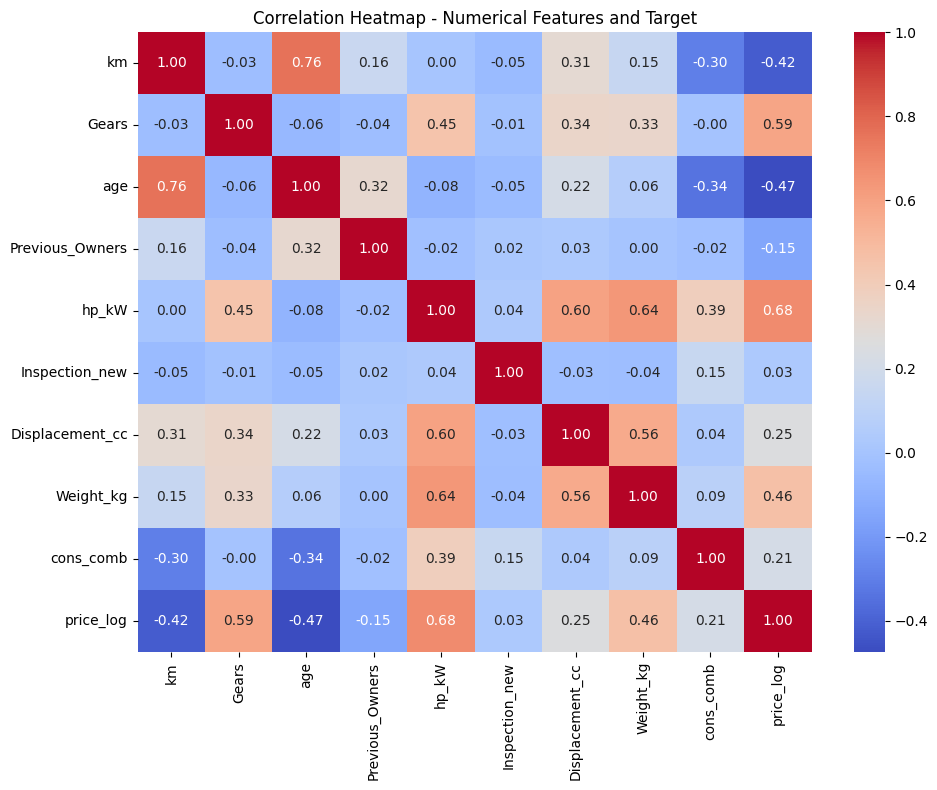

In [14]:
# Visualise correlation
numerical_df = df_1.select_dtypes(include=['int64', 'float64'])
corr_with_target = numerical_df.corr().sort_values('price_log', ascending=False)['price_log']
display(corr_with_target)

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Correlation Heatmap - Numerical Features and Target')
plt.tight_layout()
plt.show()

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.


Average target (price) for top categories in: make_model
make_model
Renault Espace    10.271688
Audi A3            9.928115
Opel Insignia      9.912605
Audi A1            9.817587
Opel Astra         9.625972
Other              9.504817
Renault Clio       9.335730
Opel Corsa         9.275962
Name: price_log, dtype: float64

Average target (price) for top categories in: make_model


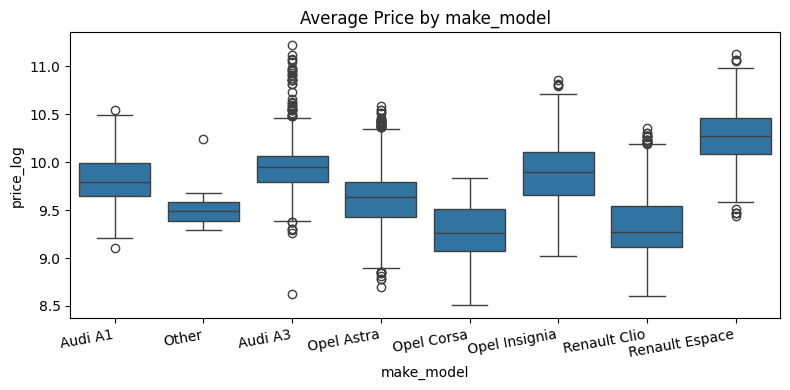


Average target (price) for top categories in: body_type
body_type
Van              10.294505
Station wagon     9.753394
Sedans            9.716079
Other             9.622857
Compact           9.555660
Name: price_log, dtype: float64

Average target (price) for top categories in: body_type


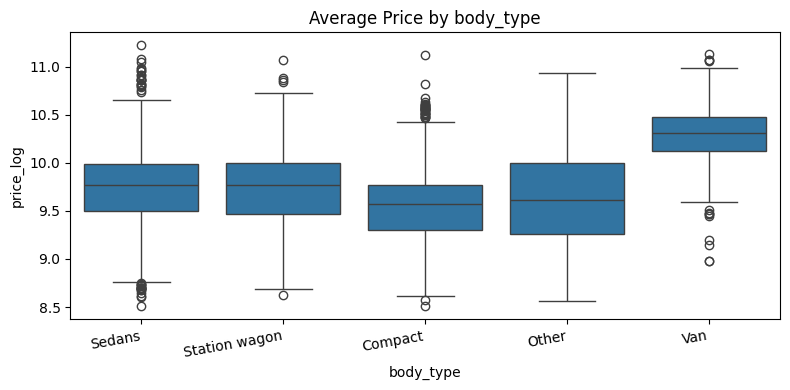


Average target (price) for top categories in: vat
vat
VAT deductible      9.730221
Price negotiable    9.556223
Name: price_log, dtype: float64

Average target (price) for top categories in: vat


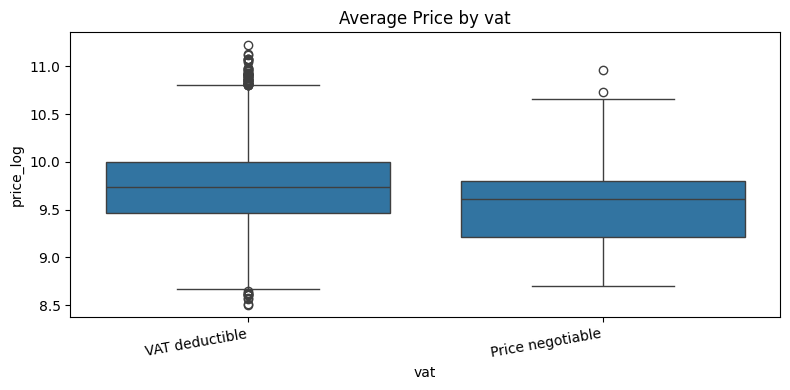


Average target (price) for top categories in: Type
Type
Like New    9.928334
Used        9.630496
Name: price_log, dtype: float64

Average target (price) for top categories in: Type


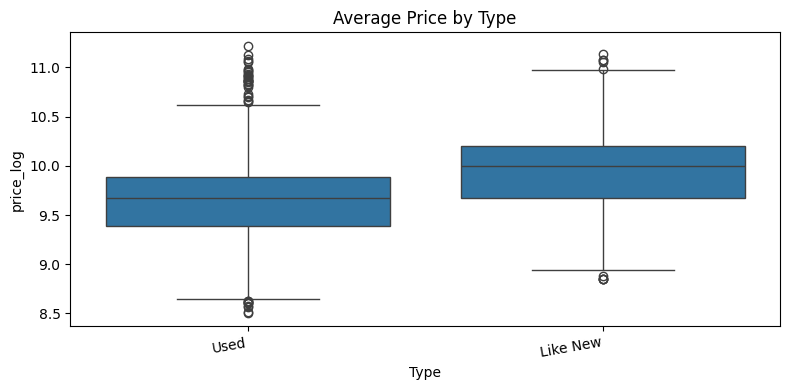


Average target (price) for top categories in: Fuel
Fuel
Diesel     9.734862
Benzine    9.709263
Other      9.639389
Name: price_log, dtype: float64

Average target (price) for top categories in: Fuel


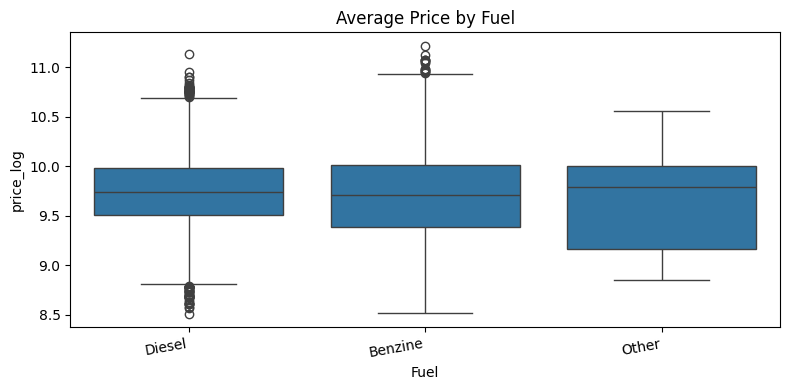


Average target (price) for top categories in: Paint_Type
Paint_Type
Metallic     9.725340
Uni/basic    9.638571
Other        9.144455
Name: price_log, dtype: float64

Average target (price) for top categories in: Paint_Type


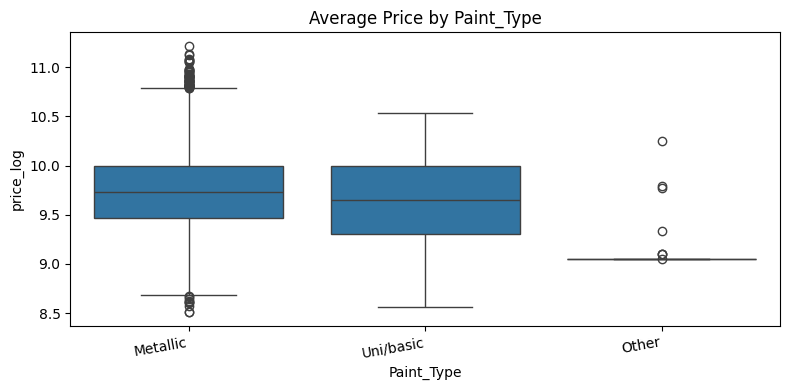


Average target (price) for top categories in: Upholstery_type
Upholstery_type
Part/Full Leather    9.981333
Cloth                9.642278
Name: price_log, dtype: float64

Average target (price) for top categories in: Upholstery_type


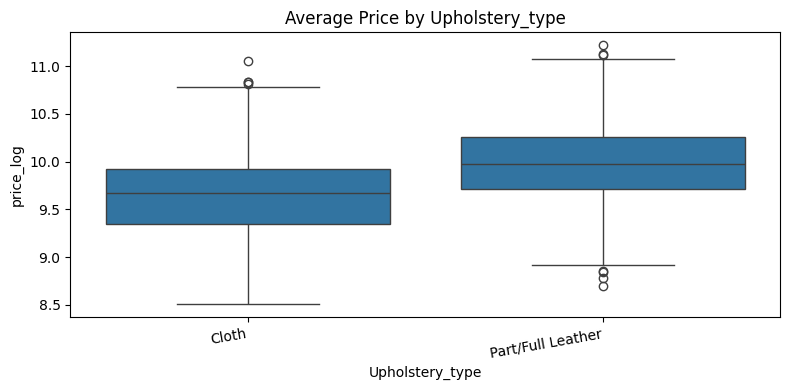


Average target (price) for top categories in: Gearing_Type
Gearing_Type
Semi-automatic    9.971954
Automatic         9.906124
Manual            9.540199
Name: price_log, dtype: float64

Average target (price) for top categories in: Gearing_Type


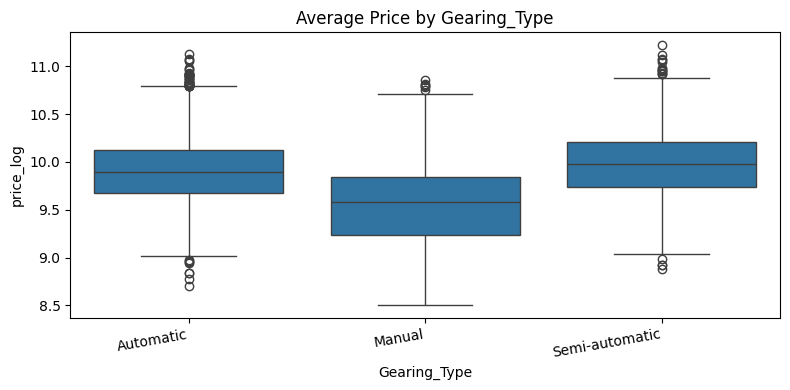


Average target (price) for top categories in: Drive_chain
Drive_chain
4WD      10.133446
front     9.715367
Other     9.606097
Name: price_log, dtype: float64

Average target (price) for top categories in: Drive_chain


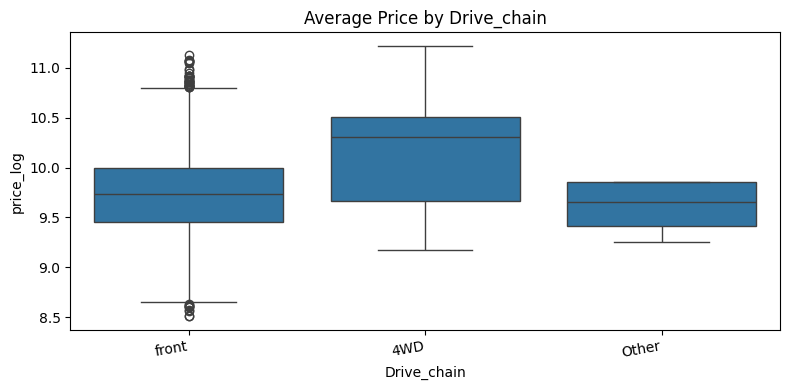

In [15]:
# Comparing average values of target for different categories
for col in plot_cols:
    avg_price = df_1.groupby(col)['price_log'].mean().sort_values(ascending=False)
    print(f"\nAverage target (price) for top categories in: {col}")
    print(avg_price)

    print(f"\nAverage target (price) for top categories in: {col}")
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='price_log', data=df_1)
    plt.title(f'Average Price by {col}')
    plt.xlabel(col)
    plt.ylabel('price_log')
    plt.xticks(rotation=10, ha='right')
    plt.tight_layout()
    plt.show()

In [16]:
cols = ["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]

for col in cols:
    avg_price = df_1.groupby(col)['price_log'].mean().sort_values(ascending=False)
    print(f"\nAverage target (price) for top categories in: {col}")
    display(avg_price)


Average target (price) for top categories in: Comfort_Convenience


Comfort_Convenience
Air conditioning,Armrest,Automatic climate control,Cruise control,Electrically adjustable seats,Electrical side mirrors,Electric tailgate,Heated steering wheel,Hill Holder,Keyless central door lock,Leather steering wheel,Light sensor,Lumbar support,Multi-function steering wheel,Navigation system,Park Distance Control,Parking assist system camera,Parking assist system sensors front,Parking assist system sensors rear,Power windows,Rain sensor,Seat heating,Start-stop system    10.017434
Air conditioning,Automatic climate control,Cruise control,Multi-function steering wheel,Park Distance Control,Power windows                                                                                                                                                                                                                                                                                                                                                                     9.898697
Ai


Average target (price) for top categories in: Entertainment_Media


Entertainment_Media
Bluetooth,Digital radio,Hands-free equipment,On-board computer,Radio,USB                               10.018336
Bluetooth,Hands-free equipment,On-board computer,Radio                                                  9.963639
Bluetooth,Digital radio,Hands-free equipment,MP3,On-board computer,Radio,USB                            9.911254
Bluetooth,Radio                                                                                         9.857451
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio,Sound system,USB                   9.819183
Bluetooth,CD player,Digital radio,Hands-free equipment,MP3,On-board computer,Radio,Sound system,USB     9.784328
Other                                                                                                   9.770646
Bluetooth,Hands-free equipment,On-board computer,Radio,Sound system,USB                                 9.743768
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio        


Average target (price) for top categories in: Extras


Extras
Alloy wheels,Sport suspension                        9.942485
Alloy wheels,Roof rack,Touch screen,Voice Control    9.896199
Alloy wheels,Catalytic Converter,Voice Control       9.892244
Alloy wheels,Sport seats,Sport suspension            9.870610
Alloy wheels,Roof rack                               9.836637
Alloy wheels,Touch screen,Voice Control              9.831290
Alloy wheels,Touch screen                            9.825564
Alloy wheels,Catalytic Converter,Touch screen        9.813384
Other                                                9.807617
Alloy wheels,Sport seats                             9.793544
Alloy wheels,Voice Control                           9.785707
Alloy wheels,Catalytic Converter                     9.762595
Alloy wheels,Sport seats,Voice Control               9.759408
Alloy wheels                                         9.629836
Alloy wheels,Roof rack,Touch screen                  9.617564
Touch screen                                         9.498816
R


Average target (price) for top categories in: Safety_Security


Safety_Security
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon headlights                         9.929989
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon headlights              9.774858
Other                                                                                                                                                                                                                                                      9.755703
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,LED Daytime Running Lights,Passenger-side airbag,Power steering,Side airbag,Tire 

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [17]:
def outlier_distribution(df, cols):
    stats_dict = {}
    for c in cols:
        stats_dict[c] = {
            'count': df[c].count(),
            'mean': df[c].mean(),
            'std': df[c].std(),
            'min': df[c].min(),
            'Q_01': df[c].quantile(0.01),
            'Q_05': df[c].quantile(0.05),
            'Q_10': df[c].quantile(0.10),
            'Q_25': df[c].quantile(0.25),
            'Q_50': df[c].quantile(0.50),
            'Q_75': df[c].quantile(0.75),
            'Q_90': df[c].quantile(0.90),
            'Q_95': df[c].quantile(0.95),
            'Q_99': df[c].quantile(0.99),
            'max': df[c].max()}

    # Consolidate into a single DataFrame
    dist_df = pd.DataFrame(stats_dict).T
    return dist_df.round(2)

# Identify numerical columns
numerical_cols = df_1.select_dtypes(include=['int64', 'float64']).columns

# Generate and display the table
distribution_table = outlier_distribution(df_1, numerical_cols)
distribution_table

,count,mean,std,min,Q_01,Q_05,Q_10,Q_25,Q_50,Q_75,Q_90,Q_95,Q_99,max
km,15915.0,32090.00,36977.21,0.00,1.00,10.00,10.00,1920.50,20413.00,46900.00,87999.0,109930.00,154987.40,317000.00
Gears,15915.0,5.94,0.70,5.00,5.00,5.00,5.00,5.00,6.00,6.00,7.0,7.00,8.00,8.00
age,15915.0,1.39,1.12,0.00,0.00,0.00,0.00,0.00,1.00,2.00,3.0,3.00,3.00,3.00
Previous_Owners,15915.0,1.04,0.34,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.0,2.00,2.00,4.00
hp_kW,15915.0,88.50,26.67,40.00,51.00,54.00,55.00,66.00,85.00,103.00,122.0,146.00,165.00,294.00
Inspection_new,15915.0,0.25,0.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,1.00,1.00,1.00
Displacement_cc,15915.0,1428.66,275.80,890.00,898.00,999.00,999.00,1229.00,1461.00,1598.00,1618.0,1956.00,1997.00,2967.00
Weight_kg,15915.0,1337.70,199.68,840.00,1063.00,1110.00,1135.00,1165.00,1295.00,1472.00,1659.0,1734.00,1845.00,2471.00
cons_comb,15915.0,4.83,0.87,3.00,3.30,3.50,3.80,4.10,4.80,5.40,5.9,6.30,7.10,9.10
price_log,15915.0,9.72,0.40,8.51,8.88,9.04,9.18,9.46,9.74,9.99,10.2,10.37,10.61,11.22


In [18]:
# Outliers present in each column
def detect_outliers_iqr(df, cols):
    for c in cols:
        Q1 = df[c].quantile(0.01)
        Q3 = df[c].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 0.5 * IQR
        upper_bound = Q3 + 0.5 * IQR

        # Detect outliers
        outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)]

        # Count outliers only if there are any
        outliers_count = len(outliers)
        if outliers_count > 0:
            print(f"{c}: {outliers_count} outliers")

detect_outliers_iqr(df_1, numerical_cols)

km: 5 outliers
Previous_Owners: 2 outliers
hp_kW: 23 outliers
Displacement_cc: 1 outliers
Weight_kg: 49 outliers
cons_comb: 1 outliers


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [19]:
# Handle outliers
df_clean = df_1.copy()

def Handle_outliers_iqr_winsorization(df, cols):
    for c in cols:
        lower_bound = df[c].quantile(0.01)
        upper_bound = df[c].quantile(0.99)

        # Cap values outside the bounds
        df[c] = np.where(df[c] < lower_bound, lower_bound,
                       np.where(df[c] > upper_bound, upper_bound, df[c]))

cols = ['km', 'hp_kW', 'Weight_kg', 'Displacement_cc', 'cons_comb']
Handle_outliers_iqr_winsorization(df_clean,cols)

In [20]:
df_clean.shape

(15915, 23)

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [21]:
# Fix/create columns as needed
df_final = df_clean.drop(['vat'], axis=1)

# df_final['power_to_weight'] = df_final['hp_kW'] / df_final['Weight_kg']

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [22]:
# Check unique values in each feature spec column
spec_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in spec_cols:
    items = df[col].str.get_dummies(sep=',')
    freq = items.mean()
    relevant_items = freq[(freq > 0.1) & (freq < 0.9)].index
    df_final = pd.concat([df_final, items[relevant_items].add_prefix(col + '_')], axis=1)

In [23]:
non_relevant_items = freq[(freq < 0.1) |(freq > 0.9)].index
print(f'Non-relevant items: {non_relevant_items}')

Non-relevant items: Index(['ABS', 'Adaptive Cruise Control', 'Blind spot monitor',
       'Driver drowsiness detection', 'Driver-side airbag', 'Emergency system',
       'Night view assist', 'Passenger-side airbag', 'Power steering',
       'Rear airbag'],
      dtype='object')


Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [24]:
# Drop features from df
df_final = df_final.drop(columns=spec_cols)

In [25]:
df_final.shape

(15915, 74)

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [26]:
# Encode features
categorical_cols = df_final.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_final, columns=categorical_cols,drop_first=True)
print('Encoded shape:', df_encoded.shape)

Encoded shape: (15915, 87)


In [27]:
df_encoded.head()

,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb,price_log,...,Type_Used,Fuel_Diesel,Fuel_Other,Paint_Type_Other,Paint_Type_Uni/basic,Upholstery_type_Part/Full Leather,Gearing_Type_Manual,Gearing_Type_Semi-automatic,Drive_chain_Other,Drive_chain_front
0,56013.0,7.0,3.0,2.0,66.0,1,1422.0,1220.0,3.8,9.665865,...,True,True,False,False,False,False,False,False,False,True
1,80000.0,7.0,2.0,1.0,141.0,0,1798.0,1255.0,5.6,9.581904,...,True,False,False,False,False,False,False,False,False,True
2,83450.0,7.0,3.0,1.0,85.0,0,1598.0,1135.0,3.8,9.591513,...,True,True,False,False,False,False,False,False,False,True
3,73000.0,6.0,3.0,1.0,66.0,0,1422.0,1195.0,3.8,9.581904,...,True,True,False,False,False,False,False,False,False,True
4,16200.0,7.0,3.0,1.0,66.0,1,1422.0,1135.0,4.1,9.728539,...,True,True,False,False,False,False,False,False,False,True


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [28]:
# Split data
X = df_encoded.drop(['price_log'], axis=1)
y = df_encoded['price_log']

In [29]:
X.describe()

,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb,Comfort_Convenience_Armrest,...,Safety_Security_Immobilizer,Safety_Security_Isofix,Safety_Security_LED Daytime Running Lights,Safety_Security_LED Headlights,Safety_Security_Lane departure warning system,Safety_Security_Side airbag,Safety_Security_Tire pressure monitoring system,Safety_Security_Traction control,Safety_Security_Traffic sign recognition,Safety_Security_Xenon headlights
count,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,...,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000
mean,31860.385592,5.937355,1.389695,1.042853,88.309394,0.247063,1427.984229,1335.857619,4.828762,0.477537,...,0.704744,0.797298,0.371348,0.207791,0.199686,0.879548,0.727427,0.744266,0.129312,0.232045
std,36042.845809,0.704772,1.121306,0.339178,25.699541,0.431317,273.758577,191.893484,0.848981,0.499511,...,0.456172,0.402025,0.483180,0.405739,0.399777,0.325500,0.445297,0.436286,0.335555,0.422151
min,1.000000,5.000000,0.000000,0.000000,51.000000,0.000000,898.000000,1063.000000,3.300000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1920.500000,5.000000,0.000000,1.000000,66.000000,0.000000,1229.000000,1165.000000,4.100000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,20413.000000,6.000000,1.000000,1.000000,85.000000,0.000000,1461.000000,1295.000000,4.800000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,46900.000000,6.000000,2.000000,1.000000,103.000000,0.000000,1598.000000,1472.000000,5.400000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,154987.400000,8.000000,3.000000,4.000000,165.000000,1.000000,1997.000000,1845.000000,7.100000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (12732, 86)
Testing set shape: (3183, 86)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [31]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [32]:
# Initialise and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# Evaluate the model's performance
y_pred_lr = lr_model.predict(X_test_scaled)
y_train_pred_lr = lr_model.predict(X_train_scaled)

In [34]:
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

In [35]:
def regression_metrics(y_train, y_train_pred, y_test, y_test_pred):
    def compute_metrics(y, y_pred):
        # Compute evaluation metrics
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        mape = mean_absolute_percentage_error(y, y_pred) * 100
        r2 = r2_score(y, y_pred)

        # Compute statistics for comparison
        var = y.var()  # Compares to the MSE
        std = y.std()  # Compares to the RMSE
        mean_val = y.mean()  # Acts as the 'typical value' when comparing to the MAE

        return mse, var, rmse, std, mae, mean_val, mape, r2

    metrics_train = compute_metrics(y_train, y_train_pred)
    metrics_test = compute_metrics(y_test, y_test_pred)

    return pd.DataFrame({'Dataset': ['Training', 'Testing'], 'MSE': [metrics_train[0], metrics_test[0]], 'Var': [metrics_train[1], metrics_test[1]],
                         'RMSE': [metrics_train[2], metrics_test[2]], 'Std Dev': [metrics_train[3], metrics_test[3]],
                         'MAE': [metrics_train[4], metrics_test[4]], 'Mean': [metrics_train[5], metrics_test[5]],'MAPE': [metrics_train[6], metrics_test[6]],
                         'R²': [metrics_train[7], metrics_test[7]]}).set_index('Dataset')

In [36]:
regression_metrics(y_train, y_train_pred_lr, y_test, y_pred_lr)

,MSE,Var,RMSE,Std Dev,MAE,Mean,MAPE,R²
Dataset,,,,,,,,
Training,0.011776,0.158268,0.108519,0.397830,0.080082,9.722581,0.822428,0.925587
Testing,0.011079,0.159913,0.105259,0.399891,0.078748,9.713171,0.808364,0.930694


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

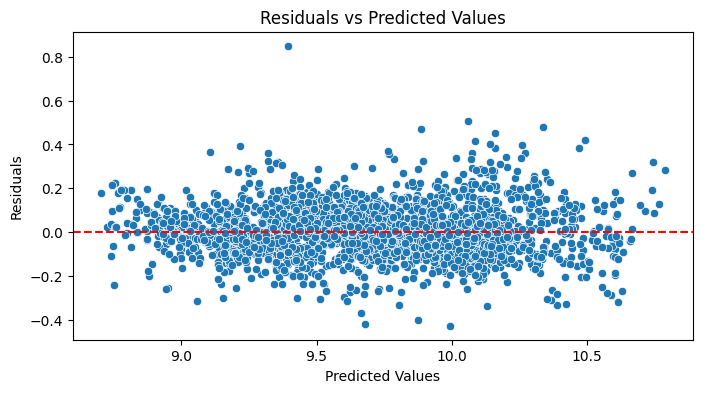

In [37]:
# Linearity check: Plot residuals vs fitted values
residuals = y_test - y_pred_lr
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

Check normality in residual distribution

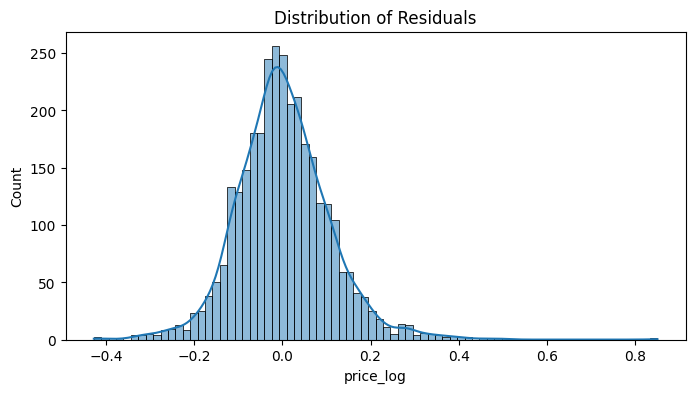

In [38]:
# Check the normality of residuals by plotting their distribution
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

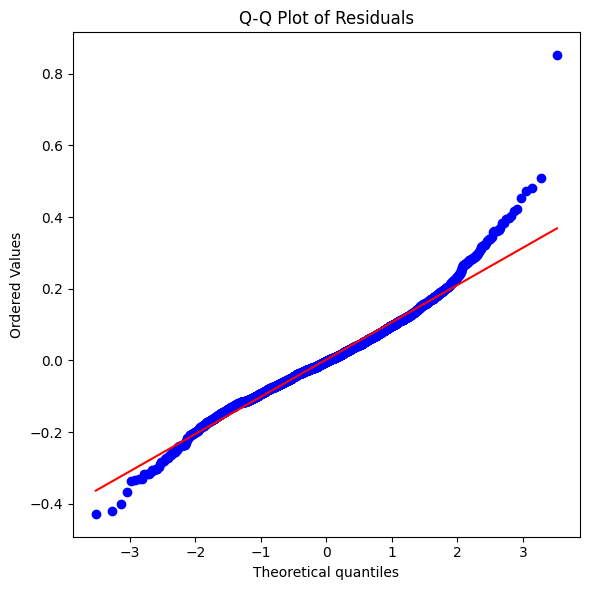

In [39]:
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

In [40]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_model.coef_})
feature_importance = feature_importance.assign(abs_coefficient=lambda d: d['Coefficient'].abs())
feature_importance.sort_values('abs_coefficient', ascending=False).head(15).reset_index(drop=True)

,Feature,Coefficient,abs_coefficient
0,make_model_Opel Corsa,-0.153146,0.153146
1,make_model_Renault Clio,-0.130708,0.130708
2,hp_kW,0.101219,0.101219
3,age,-0.099056,0.099056
4,km,-0.087647,0.087647
5,make_model_Opel Astra,-0.084210,0.084210
6,Gearing_Type_Manual,-0.057991,0.057991
7,make_model_Audi A3,0.035825,0.035825
8,make_model_Renault Espace,0.034674,0.034674
9,make_model_Opel Insignia,-0.030594,0.030594


Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [41]:
# Check for multicollinearity and handle
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe):
    vif_data = []
    for i in range(dataframe.shape[1]):
        vif_value = variance_inflation_factor(dataframe.values, i)
        vif_data.append({'feature': dataframe.columns[i], 'VIF': vif_value})
    return pd.DataFrame(vif_data)

In [42]:
X_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
vif_df = calculate_vif(X_scaled_df)
vif_df = vif_df.sort_values('VIF', ascending = False)
vif_df.round(3).set_index('feature').head(15)

,VIF
feature,
make_model_Renault Espace,10.044
hp_kW,8.408
Fuel_Diesel,6.973
Displacement_cc,6.958
make_model_Opel Insignia,6.900
body_type_Van,6.812
make_model_Opel Corsa,5.226
Weight_kg,5.079
Comfort_Convenience_Parking assist system sensors rear,4.950


In [43]:
print(f'very less correlation: {(vif_df["VIF"] < 1).sum()}')
print(f'mild correlation : {((vif_df["VIF"] >= 1) & (vif_df["VIF"] <= 5)).sum()}')
print(f'moderately correlation : {((vif_df["VIF"] > 5) & (vif_df["VIF"] <= 10)).sum()}')
print(f'strong correlation: {(vif_df["VIF"] > 10).sum()}')

very less correlation: 0
mild correlation : 78
moderately correlation : 7
strong correlation: 1


In [44]:
high_vif = vif_df[vif_df["VIF"] > 10]["feature"].tolist()
high_vif

['make_model_Renault Espace']

In [45]:
columns_to_drop = [col for col in high_vif if col in X_scaled_df.columns]

# Drop the identified high VIF columns

X_train_vif = X_scaled_df.drop(columns=columns_to_drop)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_vif = X_test_scaled_df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns due to high VIF.")

Dropped 1 columns due to high VIF.


In [46]:
X_test_scaled.shape

(3183, 86)

In [47]:
from sklearn.feature_selection import RFE
estimator = LinearRegression()

n_features_to_keep = 40

rfe = RFE(estimator, n_features_to_select=n_features_to_keep)
rfe.fit(X_train_vif, y_train)

selected_features = X_train_vif.columns[rfe.support_]
dropped_features = X_train_vif.columns[~rfe.support_]

X_rfe = X_train_vif[selected_features]

print("\n===== RFE RESULTS =====")
print("Selected features:", len(selected_features))
print(selected_features.tolist())
print("\nDropped features:", len(dropped_features))
print(dropped_features.tolist())

print("\nFINAL FEATURE SET SHAPE:", X_rfe.shape)


===== RFE RESULTS =====
Selected features: 40
['km', 'Gears', 'age', 'hp_kW', 'Displacement_cc', 'cons_comb', 'Comfort_Convenience_Cruise control', 'Comfort_Convenience_Heated steering wheel', 'Comfort_Convenience_Leather steering wheel', 'Comfort_Convenience_Lumbar support', 'Comfort_Convenience_Navigation system', 'Comfort_Convenience_Park Distance Control', 'Comfort_Convenience_Parking assist system camera', 'Comfort_Convenience_Seat heating', 'Comfort_Convenience_Split rear seats', 'Entertainment_Media_Digital radio', 'Entertainment_Media_USB', 'Extras_Alloy wheels', 'Extras_Voice Control', 'Safety_Security_Central door lock', 'Safety_Security_Central door lock with remote control', 'Safety_Security_Immobilizer', 'Safety_Security_Isofix', 'Safety_Security_LED Daytime Running Lights', 'Safety_Security_LED Headlights', 'Safety_Security_Lane departure warning system', 'Safety_Security_Xenon headlights', 'make_model_Audi A3', 'make_model_Opel Astra', 'make_model_Opel Corsa', 'make_mod

In [48]:
X_train_rfe, X_test_rfe = X_train_vif[selected_features], X_test_vif[selected_features]

In [49]:
print(f'Training set shape: {X_train_rfe.shape}')
print(f'Testing set shape: {X_test_rfe.shape}')

Training set shape: (12732, 40)
Testing set shape: (3183, 40)


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [50]:
# List of alphas to tune for Ridge regularisation
param_grid_ridge = {'alpha': np.linspace(0.001, 40, 1000)}

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [51]:
# Applying Ridge regression
ridge = Ridge()

# GridSearchCV for tuning Ridge hyperparameters
ridge_cv = GridSearchCV(estimator=ridge, param_grid = param_grid_ridge,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

ridge_cv.fit(X_train_rfe, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'alpha': array([1.0000...00000000e+01])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

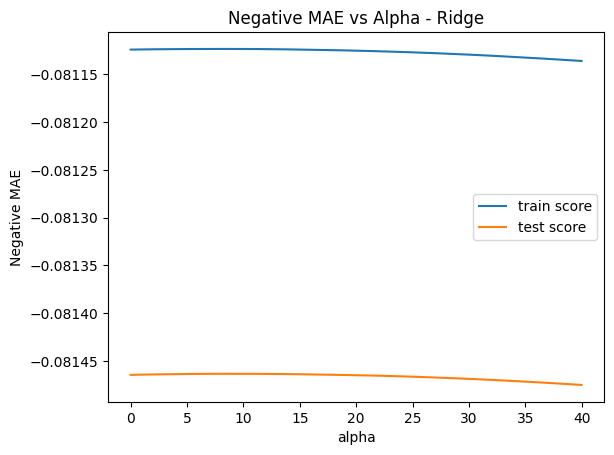

In [52]:
# Plot train and test scores against alpha
res = pd.DataFrame(ridge_cv.cv_results_)

plt.plot(res['param_alpha'], res['mean_train_score'], label='train score')
plt.plot(res['param_alpha'], res['mean_test_score'], label='test score')
plt.xlabel('alpha')
plt.ylabel('Negative MAE')
plt.title("Negative MAE vs Alpha - Ridge")
plt.legend()
plt.show()

Find the best alpha value.

In [53]:
# Best alpha value
best_ridge_alpha = ridge_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha:.4f}")

# Best score (negative MAE)
best_score = ridge_cv.best_score_
print(f"Best negative MAE: {-best_score:.4f}")

Best alpha: 9.6904
Best negative MAE: 0.0815


In [54]:
y_pred_ridge = ridge_cv.predict(X_test_rfe)
y_train_pred_ridge = ridge_cv.predict(X_train_rfe)

regression_metrics(y_train, y_train_pred_ridge, y_test, y_pred_ridge)

,MSE,Var,RMSE,Std Dev,MAE,Mean,MAPE,R²
Dataset,,,,,,,,
Training,0.012108,0.158268,0.110037,0.397830,0.081149,9.722581,0.833271,0.923490
Testing,0.011351,0.159913,0.106540,0.399891,0.079867,9.713171,0.819904,0.928996


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [55]:
# Take a smaller range of alpha to test
ridge_grid_fine = {'alpha': np.linspace(5, 15, 100)}

In [56]:
# Applying Ridge regression
ridge = Ridge()

# GridSearchCV for tuning Ridge hyperparameters
ridge_cv = GridSearchCV(estimator=ridge, param_grid = ridge_grid_fine,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

ridge_cv.fit(X_train_rfe, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'alpha': array([ 5. ... 15. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

Plot the error-alpha graph again and find the actual optimal value for alpha.

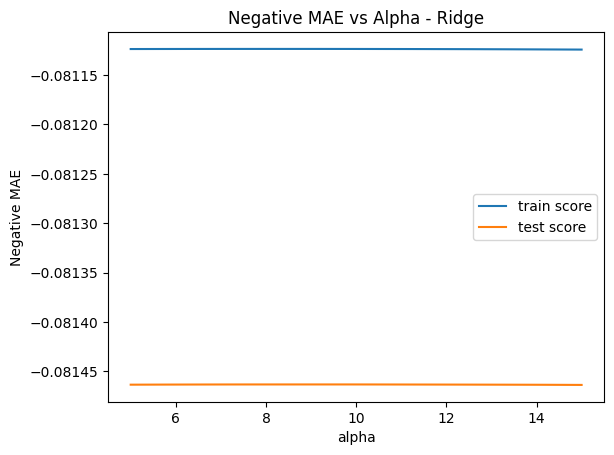

Best alpha: 9.6465
Best negative MAE: 0.0815


In [57]:
# Plot train and test scores against alpha
res = pd.DataFrame(ridge_cv.cv_results_)

plt.plot(res['param_alpha'], res['mean_train_score'], label='train score')
plt.plot(res['param_alpha'], res['mean_test_score'], label='test score')
plt.xlabel('alpha')
plt.ylabel('Negative MAE')
plt.title("Negative MAE vs Alpha - Ridge")
plt.legend()
plt.show()

# Best alpha value
best_ridge_alpha = ridge_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha:.4f}")

# Best score (negative MAE)
best_score = ridge_cv.best_score_
print(f"Best negative MAE: {-best_score:.4f}")

In [58]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
final_ridge = Ridge(alpha=best_ridge_alpha)
final_ridge.fit(X_train_rfe, y_train)
print(f'Final Ridge model fitted with alpha: {best_ridge_alpha:.4f}')

Final Ridge model fitted with alpha: 9.6465


In [59]:
coef_df = (pd.DataFrame({
    'feature': X_train_rfe.columns,
    'coefficient': final_ridge.coef_
})
.assign(abs_coef=lambda d: d['coefficient'].abs())
.sort_values('abs_coef', ascending=False))

print("Top 15 features by absolute coefficient:")
display(coef_df.head(15))

print("Bottom 15 features by absolute coefficient:")
display(coef_df.tail(15))

Top 15 features by absolute coefficient:


,feature,coefficient,abs_coef
29,make_model_Opel Corsa,-0.154408,0.154408
32,make_model_Renault Clio,-0.132681,0.132681
3,hp_kW,0.107711,0.107711
2,age,-0.098596,0.098596
28,make_model_Opel Astra,-0.092488,0.092488
0,km,-0.087585,0.087585
37,Gearing_Type_Manual,-0.058308,0.058308
30,make_model_Opel Insignia,-0.043515,0.043515
27,make_model_Audi A3,0.027847,0.027847
31,make_model_Other,-0.021619,0.021619


Bottom 15 features by absolute coefficient:


,feature,coefficient,abs_coef
20,Safety_Security_Central door lock with remote ...,-0.009282,0.009282
6,Comfort_Convenience_Cruise control,0.009042,0.009042
9,Comfort_Convenience_Lumbar support,-0.009014,0.009014
4,Displacement_cc,-0.008470,0.008470
5,cons_comb,0.008311,0.008311
13,Comfort_Convenience_Seat heating,0.006894,0.006894
39,Drive_chain_front,-0.006890,0.006890
10,Comfort_Convenience_Navigation system,0.006220,0.006220
23,Safety_Security_LED Daytime Running Lights,-0.006169,0.006169
22,Safety_Security_Isofix,-0.006022,0.006022


In [60]:
# Evaluate the Ridge model on the test data
y_pred_ridge = final_ridge.predict(X_test_rfe)
y_train_pred_ridge = final_ridge.predict(X_train_rfe)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)
regression_metrics(y_train, y_train_pred_ridge, y_test, y_pred_ridge)

,MSE,Var,RMSE,Std Dev,MAE,Mean,MAPE,R²
Dataset,,,,,,,,
Training,0.012108,0.158268,0.110037,0.397830,0.081149,9.722581,0.833271,0.923490
Testing,0.011351,0.159913,0.106540,0.399891,0.079867,9.713171,0.819904,0.928996


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [61]:
# List of alphas to tune for Lasso regularisation
param_grid_lasso = {'alpha': np.linspace(0.0000001, 0.001, 1000)}

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Lasso Regularisation and find the best value of alpha from the list

In [62]:
# Initialise Lasso regression model
lasso = Lasso()
lasso_cv = GridSearchCV(estimator=lasso, param_grid = param_grid_lasso,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

# Fit the model
lasso_cv.fit(X_train_rfe, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'alpha': array([1.0000...00000000e-03])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

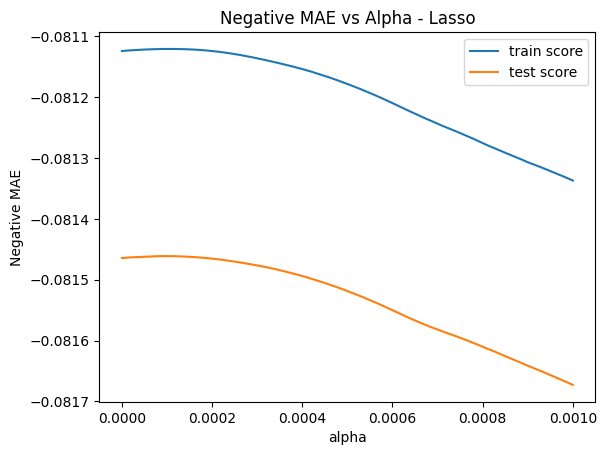

In [63]:
# Plot train and test scores against alpha
res = pd.DataFrame(lasso_cv.cv_results_)

plt.plot(res['param_alpha'], res['mean_train_score'], label='train score')
plt.plot(res['param_alpha'], res['mean_test_score'], label='test score')
plt.xlabel('alpha')
plt.ylabel('Negative MAE')
plt.title("Negative MAE vs Alpha - Lasso")
plt.legend()
plt.show()

In [64]:
# Best alpha value
best_lasso_alpha = lasso_cv.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

# Best score (negative MAE)
best_lasso_score = lasso_cv.best_score_
print(f"Best negative MAE: {-best_lasso_score:.4f}")

Best alpha: 0.00010019009009009009
Best negative MAE: 0.0815


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [65]:
# List of alphas to tune for Lasso regularization
lasso_grid_fine = {'alpha' : np.linspace(0.0000001, 0.00003, 100)}

In [66]:
# Tuning Lasso hyperparameters
lasso = Lasso()

lasso_cv_fine = GridSearchCV(estimator=lasso, param_grid=lasso_grid_fine,
                        scoring="neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

lasso_cv_fine.fit(X_train_rfe, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'alpha': array([1.0000...00000000e-05])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

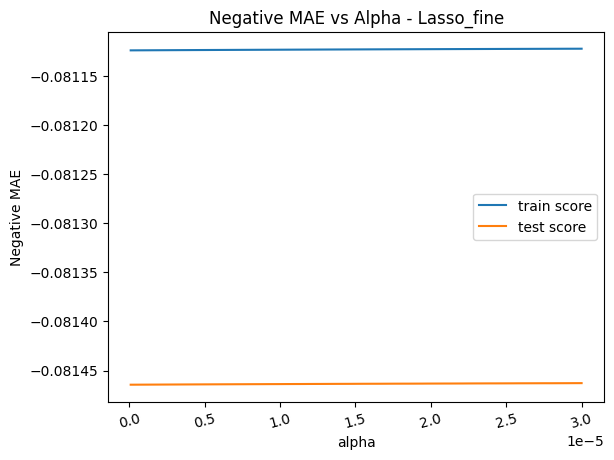

In [67]:
# Plot train and test scores against alpha
res = pd.DataFrame(lasso_cv_fine.cv_results_)

plt.plot(res['param_alpha'], res['mean_train_score'], label='train score')
plt.plot(res['param_alpha'], res['mean_test_score'], label='test score')
plt.xlabel('alpha')
plt.ylabel('Negative MAE')
plt.title("Negative MAE vs Alpha - Lasso_fine")
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [68]:
# Best alpha value
best_lasso_alpha = lasso_cv_fine.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

# Best score (negative MAE)
best_lasso_score = lasso_cv_fine.best_score_
print(f"Best negative MAE: {-best_score:.4f}")

Best alpha: 3e-05
Best negative MAE: 0.0815


In [69]:
# Set best alpha for Lasso regression
final_lasso = Lasso(alpha=best_lasso_alpha)
final_lasso.fit(X_train_rfe, y_train)
print(f'Final Lasso model fitted with alpha: {best_lasso_alpha}')

# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model
y_pred_lasso = final_lasso.predict(X_test_rfe)
y_train_pred_lasso = final_lasso.predict(X_train_rfe)

Final Lasso model fitted with alpha: 3e-05


In [70]:
# Check the coefficients for each feature
coef_df = (pd.DataFrame({
    'feature': X_train_rfe.columns,
    'coefficient': final_lasso.coef_
})
.assign(abs_coef=lambda d: d['coefficient'].abs())
.sort_values('abs_coef', ascending=False))

print("Top 15 features by absolute coefficient:")
display(coef_df.head(15))

print("Bottom 15 features by absolute coefficient:")
display(coef_df.tail(15))

Top 15 features by absolute coefficient:


,feature,coefficient,abs_coef
29,make_model_Opel Corsa,-0.154880,0.154880
32,make_model_Renault Clio,-0.133059,0.133059
3,hp_kW,0.107722,0.107722
2,age,-0.098736,0.098736
28,make_model_Opel Astra,-0.092870,0.092870
0,km,-0.087557,0.087557
37,Gearing_Type_Manual,-0.058437,0.058437
30,make_model_Opel Insignia,-0.043825,0.043825
27,make_model_Audi A3,0.027631,0.027631
31,make_model_Other,-0.021655,0.021655


Bottom 15 features by absolute coefficient:


,feature,coefficient,abs_coef
20,Safety_Security_Central door lock with remote ...,-0.009213,0.009213
6,Comfort_Convenience_Cruise control,0.009092,0.009092
9,Comfort_Convenience_Lumbar support,-0.009027,0.009027
5,cons_comb,0.008271,0.008271
4,Displacement_cc,-0.008190,0.008190
39,Drive_chain_front,-0.006851,0.006851
13,Comfort_Convenience_Seat heating,0.006780,0.006780
10,Comfort_Convenience_Navigation system,0.006185,0.006185
23,Safety_Security_LED Daytime Running Lights,-0.006081,0.006081
22,Safety_Security_Isofix,-0.005970,0.005970


In [71]:
# Evaluate the Lasso model on the test data
y_pred_lasso = final_lasso.predict(X_test_rfe)
y_train_pred_lasso = final_lasso.predict(X_train_rfe)

lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)
regression_metrics(y_train, y_train_pred_lasso, y_test, y_pred_lasso)

,MSE,Var,RMSE,Std Dev,MAE,Mean,MAPE,R²
Dataset,,,,,,,,
Training,0.012108,0.158268,0.110037,0.397830,0.081148,9.722581,0.833250,0.923490
Testing,0.011351,0.159913,0.106543,0.399891,0.079871,9.713171,0.819938,0.928993


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [72]:
# Compare metrics for each model
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [mae, ridge_mae, lasso_mae],
    'R2 Score': [r2, ridge_r2, lasso_r2]})

display(results)

,Model,MAE,R2 Score
0,Linear Regression,0.078748,0.930694
1,Ridge Regression,0.079867,0.928996
2,Lasso Regression,0.079871,0.928993


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [73]:
lr_rfe = LinearRegression()
lr_rfe.fit(X_train_rfe, y_train)
y_pred_lr_rfe = lr_rfe.predict(X_test_rfe)

In [74]:
# Compare highest coefficients and coefficients of eliminated features

comparison_coef_df = pd.DataFrame({
    'Feature': X_train_rfe.columns,
    'Linear': lr_rfe.coef_,
    'Ridge': final_ridge.coef_,
    'Lasso': final_lasso.coef_
})

# Sort by Lasso magnitude to see most important features
comparison_coef_df['Lasso_Abs'] = comparison_coef_df['Lasso'].abs()
print('Top 15 Influential Features (Linear, Ridge vs Lasso):')
display(comparison_coef_df.sort_values(by='Lasso_Abs', ascending=False).head(15).reset_index(drop=True))

Top 15 Influential Features (Linear, Ridge vs Lasso):


,Feature,Linear,Ridge,Lasso,Lasso_Abs
0,make_model_Opel Corsa,-0.154992,-0.154408,-0.154880,0.154880
1,make_model_Renault Clio,-0.133214,-0.132681,-0.133059,0.133059
2,hp_kW,0.107831,0.107711,0.107722,0.107722
3,age,-0.098696,-0.098596,-0.098736,0.098736
4,make_model_Opel Astra,-0.093039,-0.092488,-0.092870,0.092870
5,km,-0.087589,-0.087585,-0.087557,0.087557
6,Gearing_Type_Manual,-0.058395,-0.058308,-0.058437,0.058437
7,make_model_Opel Insignia,-0.044062,-0.043515,-0.043825,0.043825
8,make_model_Audi A3,0.027621,0.027847,0.027631,0.027631
9,make_model_Other,-0.021681,-0.021619,-0.021655,0.021655


In [75]:
# Check features Lasso eliminated (coef == 0)
eliminated = comparison_coef_df[comparison_coef_df['Lasso'] == 0]['Feature']
print(f'\nNumber of features eliminated by Lasso: {len(eliminated)}')


Number of features eliminated by Lasso: 0


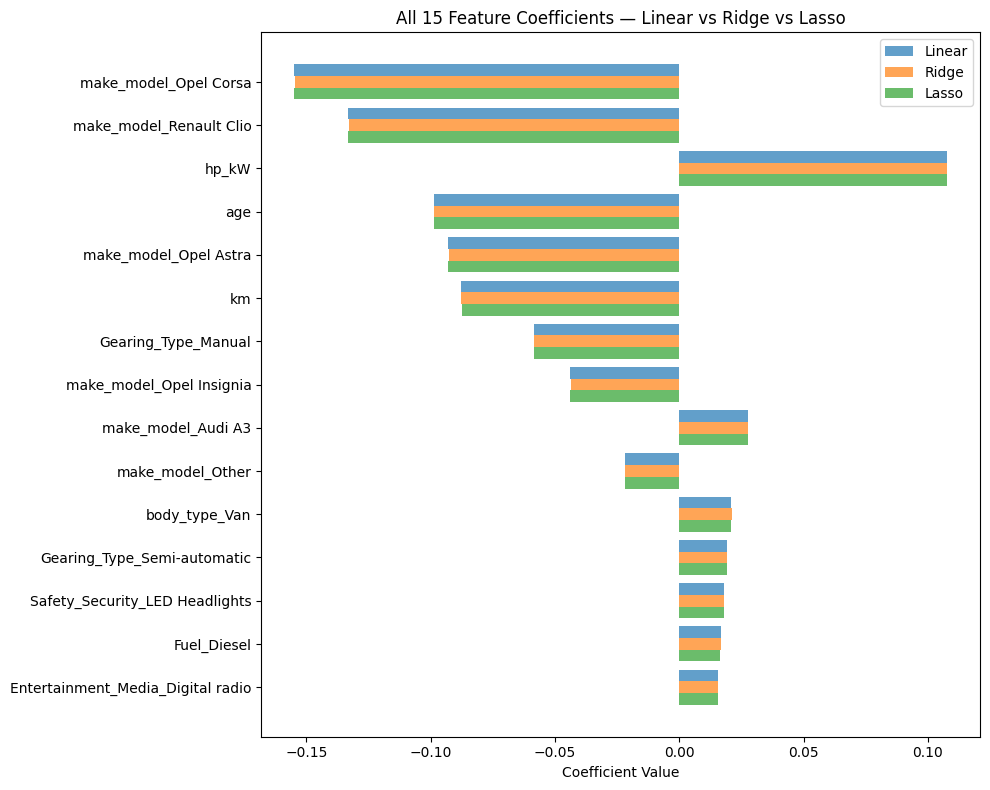

In [76]:
# Get the top 15 features by absolute Lasso coefficient from the combined dataframe
top_features_comparison = comparison_coef_df.sort_values(by='Lasso_Abs', ascending=False).head(15).reset_index(drop=True)

# Prepare data for plotting, now including 'Linear' coefficients
plot_data_comparison = top_features_comparison[['Feature', 'Linear', 'Ridge', 'Lasso']].set_index('Feature')

# Create the bar plot
top_plot_data = plot_data_comparison
y_positions = np.arange(len(top_plot_data))
bar_width = 0.27
plt.figure(figsize=(10,8))
plt.barh(y_positions + bar_width*0, top_plot_data['Linear'], height=bar_width, label='Linear', alpha=0.7)
plt.barh(y_positions + bar_width*1, top_plot_data['Ridge'],  height=bar_width, label='Ridge',  alpha=0.7)
plt.barh(y_positions + bar_width*2, top_plot_data['Lasso'],  height=bar_width, label='Lasso',  alpha=0.7)
plt.yticks(y_positions + bar_width, top_plot_data.index) # Use index (Feature names) for y-ticks
plt.gca().invert_yaxis()
plt.title('All 15 Feature Coefficients — Linear vs Ridge vs Lasso')
plt.xlabel('Coefficient Value')
plt.legend()
plt.tight_layout()
plt.show()

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

**The primary objective of this project was to develop a robust regression model to predict used car prices and identify feature importance while mitigating overfitting through regularization techniques.**

**Data Preprocessing and Feature Engineering:**
- Missing values were checked and none were found, ensuring data quality.
- Categorical features with low frequency values were grouped into 'Other' to manage cardinality and improve model stability.
- The target variable, **price**, was log-transformed (**price_log**) to address its right-skewness, making its distribution more normal and suitable for linear models.
- Features related to **Comfort_Convenience**, **Entertainment_Media**, **Extras**, and **Safety_Security** were one-hot encoded, and features with very high or low frequencies (over 90% or under 10% occurrence) were dropped to reduce dimensionality while retaining informative features.
- One categorical column with high VIF was dropped to reduce multicollinearity.
-To reduce noise from our dataset, we used **RFE(40)**, which improve model generalization and feature selection.
- All features were scaled using **StandardScaler** to ensure that no single feature dominates the model due to its scale.
- **No overfitting** was observed, as training and testing scores were very close.

**Model Performance Comparison:**
- **Linear Regression (Baseline):** The baseline Linear Regression model achieved the best R² score of 0.93066 and an MAE of 0.0788 on the test set, showing that a simple linear model can perform very well on this dataset. Ridge and Lasso regularisation methods gave slightly lower R² scores (around 0.9289) but improved the model’s stability and robustness.  Moderate Multicollinearity was identified.

- **Ridge Regression:** After tuning, the best alpha value was found to be approximately 9.6465. Ridge regression yielded an R² of 0.9289 and an MAE of 0.0792. The metrics are very close to the baseline Linear Regression, indicating that while Ridge did introduce some regularization, it did not significantly alter the model's predictive performance on this dataset. This suggests that multicollinearity, while present, did not severely degrade the performance of the basic linear model.

- **Lasso Regression:** The optimal alpha for Lasso was found to be approximately 3e-05. Lasso regression resulted in an R² of 0.9289 and an MAE of 0.0798. Similar to Ridge, Lasso’s performance was nearly identical to the baseline Linear Regression. Lasso also performed feature selection by driving 5 coefficients to zero(without RFE), effectively removing those features from the model.



<font color="yellow">**Regularisation did not significantly increase accuracy, it improved generalisation and feature selection.**


- **Did the model performance improve? If not, then why?**

  The model performance (R² and MAE) did not significantly improve with Ridge or Lasso regularization compared to the baseline Linear Regression. This indicates that the baseline model was already performing quite well, and overfitting might not have been a major issue that significantly impacted generalization performance.
- **Did you find overfitting or not?**

  No significant overfitting was observed. The Linear Regression model showed similar performance on both training (R² of 0.9256) and testing (R² of 0.9307) datasets, suggesting it generalizes well to unseen data.

- **Was the data sufficient?**

  Yes, the data was considered sufficient. The high R² scores across all models and the dataset size of 15,915 samples with rich features allowed the models to learn robust patterns effectively.

- **Is a linear model sufficient?**

  Based on the high R² scores (around 0.93) and low MAE values, a linear model (Linear Regression, Ridge, or Lasso) seems quite sufficient for predicting car prices in this context.

<font color="yellow">**Overall,Regularisation improved interpretability and reduced the influence of less important features, making the model more reliable
for deployment.**

<font color="yellow">**Since we deal with many categorical feature.In future,Random forest and XGboost model can be tested if more complex relationships need to be captured.**